# Analisis Churn Menggunakan Artificial Neural Network (ANN)
Notebook ini digunakan untuk melatih model klasifikasi ANN untuk memprediksi churn pelanggan berdasarkan dataset Telco Churn.

In [ ]:
# pip install pandas scikit-learn matplotlib seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Mengatur gaya grafik agar terlihat elegan
sns.set_theme(style="whitegrid")

In [2]:
# 1. Load Dataset
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.drop('customerID', axis=1, inplace=True)

# 2. Handle Hidden Missing Values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# 3. Binary Encoding
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    if col == 'gender':
        df[col] = df[col].map({'Female': 0, 'Male': 1})
    else:
        df[col] = df[col].map({'No': 0, 'Yes': 1})

# 4. One-Hot Encoding
multiclass_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
                   'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
                   'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multiclass_cols, drop_first=True)

print("Preprocessing Selesai. Dimensi dataset saat ini:", df.shape)

Preprocessing Selesai. Dimensi dataset saat ini: (7043, 31)


In [3]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# Feature Scaling
scaler = StandardScaler()
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Memisahkan 80% data latih dan 20% data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Data Latih: {X_train.shape[0]} baris")
print(f"Data Uji: {X_test.shape[0]} baris")

Data Latih: 5634 baris
Data Uji: 1409 baris


Memulai proses training model ANN...
Training selesai dalam 22 epoch.


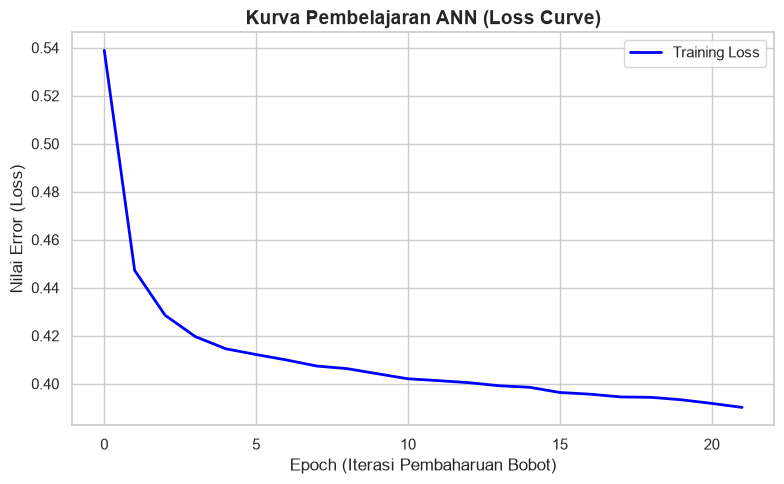

In [4]:
# Inisialisasi Model ANN
ann_model = MLPClassifier(
    hidden_layer_sizes=(64, 32), 
    activation='relu',           
    solver='adam',               
    max_iter=500,                
    random_state=42,
    early_stopping=True          
)

print("Memulai proses training model ANN...")
ann_model.fit(X_train, y_train)
print(f"Training selesai dalam {ann_model.n_iter_} epoch.")

# Visualisasi Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(ann_model.loss_curve_, color='blue', linewidth=2, label='Training Loss')
plt.title('Kurva Pembelajaran ANN (Loss Curve)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch (Iterasi Pembaharuan Bobot)', fontsize=12)
plt.ylabel('Nilai Error (Loss)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

Akurasi Keseluruhan: 79.42%

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.79      1409



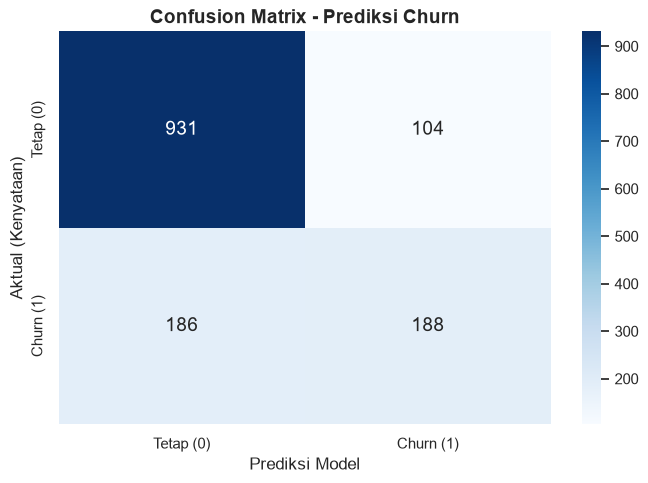

In [5]:
# Melakukan Prediksi
y_pred = ann_model.predict(X_test)

# Mencetak Teks Metrik
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Keseluruhan: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
# fmt='d' memastikan angka yang tampil adalah bilangan bulat murni
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Tetap (0)', 'Churn (1)'], 
            yticklabels=['Tetap (0)', 'Churn (1)'],
            annot_kws={"size": 14})

plt.title('Confusion Matrix - Prediksi Churn', fontsize=14, fontweight='bold')
plt.xlabel('Prediksi Model', fontsize=12)
plt.ylabel('Aktual (Kenyataan)', fontsize=12)
plt.tight_layout()
plt.show()